In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [2]:
df_train = pd.read_csv("Datasets/UNSW_NB15_training-set.csv")
df_test  = pd.read_csv("Datasets/UNSW_NB15_testing-set.csv")

print("Train shape:", df_train.shape)
print("Test shape :", df_test.shape)

Train shape: (175341, 45)
Test shape : (82332, 45)


In [3]:
drop_cols = ['id', 'attack_cat']

df_train = df_train.drop(columns=drop_cols)
df_test  = df_test.drop(columns=drop_cols)

In [4]:
X_train = df_train.drop(columns=['label'])
y_train = df_train['label']

X_test  = df_test.drop(columns=['label'])
y_test  = df_test['label']

In [5]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

num_features = X_train.select_dtypes(include=['int64','float64']).columns
cat_features = X_train.select_dtypes(include=['object']).columns

preprocessor_l1 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(
            handle_unknown='ignore',
            min_frequency=50
        ), cat_features)
    ]
)

In [6]:
from sklearn.linear_model import LogisticRegression

lr_l1_model = LogisticRegression(
    penalty='l1',
    solver='liblinear',  
    C=1.0,                
    class_weight='balanced',
    max_iter=1000
)

In [7]:
from sklearn.pipeline import Pipeline

pipeline_lr_l1 = Pipeline(steps=[
    ('preprocessing', preprocessor_l1),
    ('classifier', lr_l1_model)
])

In [8]:
start_time = time.time()
pipeline_lr_l1.fit(X_train, y_train)
training_time = time.time() - start_time

print("Training Time (s):", round(training_time, 2))

Training Time (s): 257.34


In [9]:
y_prob_l1 = pipeline_lr_l1.predict_proba(X_test)[:, 1]

THRESHOLD = 0.4
y_pred_l1 = (y_prob_l1 > THRESHOLD).astype(int)

In [10]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, y_pred_l1))
print("Precision:", precision_score(y_test, y_pred_l1))
print("Recall   :", recall_score(y_test, y_pred_l1))
print("F1 Score :", f1_score(y_test, y_pred_l1))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_l1))

Accuracy : 0.8181023174464364
Precision: 0.7683616818133597
Recall   : 0.9586384893673343
F1 Score : 0.8530179605456866
ROC-AUC  : 0.9562876441914427


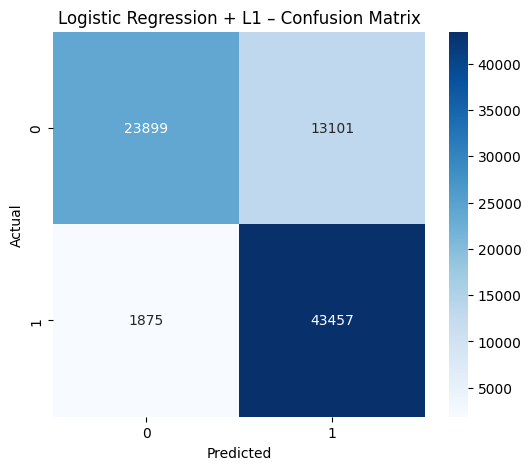

In [11]:
cm = confusion_matrix(y_test, y_pred_l1)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression + L1 – Confusion Matrix")
plt.show()

In [12]:
import joblib

joblib.dump(pipeline_lr_l1, "logistic_l1_ids_model.joblib")
print("Logistic Regression + L1 model saved")

Logistic Regression + L1 model saved
